<a href="https://colab.research.google.com/github/Krishna-Dhawangale/Resume-Screening-Machine-Learning-/blob/main/Tf_idf_resume_screening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/ML_Data/AI_Resume_Screening.csv')
df.head(20)

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100
5,6,Samantha Santos,"Cybersecurity, Networking, Linux, Ethical Hacking",10,B.Tech,Google ML,Cybersecurity Analyst,Hire,47957,5,100
6,7,Tony Smith,"Networking, Cybersecurity, Ethical Hacking",4,M.Tech,AWS Certified,Cybersecurity Analyst,Hire,66208,9,100
7,8,Anthony Harrison,"TensorFlow, Pytorch, NLP",3,M.Tech,AWS Certified,AI Researcher,Hire,103006,7,90
8,9,Nancy Jenkins,"Networking, Ethical Hacking",7,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,92270,3,100
9,10,Courtney Gibson,"Python, TensorFlow, Pytorch, NLP",0,M.Tech,AWS Certified,AI Researcher,Reject,60579,1,35


In [4]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (1000, 11)


In [5]:
print("Column names:")
print(df.columns.tolist())

Column names:
['Resume_ID', 'Name', 'Skills', 'Experience (Years)', 'Education', 'Certifications', 'Job Role', 'Recruiter Decision', 'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)']


In [6]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Resume_ID                   0
Name                        0
Skills                      0
Experience (Years)          0
Education                   0
Certifications            274
Job Role                    0
Recruiter Decision          0
Salary Expectation ($)      0
Projects Count              0
AI Score (0-100)            0
dtype: int64


In [7]:
print("Class distribution (Job Role):")
print(df['Job Role'].value_counts())

Class distribution (Job Role):
Job Role
AI Researcher            257
Data Scientist           255
Cybersecurity Analyst    255
Software Engineer        233
Name: count, dtype: int64


### Step 2: Text Preprocessing

Now, I will combine the `Skills` and `Certifications` columns into a single `text` column, as they are crucial for resume screening. Then, I'll preprocess this text data by converting it to lowercase, removing punctuation, special characters, numbers, and stopwords, and finally performing tokenization and lemmatization.

In [9]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab') # Added to download the missing resource

# Combine 'Skills' and 'Certifications' into a new 'text' column for processing
df['text'] = df['Skills'].fillna('') + ' ' + df['Certifications'].fillna('')

def preprocess_text(text):
    text = str(text).lower() # Convert to lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Remove punctuation and special characters
    text = re.sub(r'\d+', '', text) # Remove numbers
    tokens = word_tokenize(text) # Tokenization
    stop_words = set(stopwords.words('english')) # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    lemmatizer = WordNetLemmatizer() # Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

df['processed_text'] = df['text'].apply(preprocess_text)

print("Original text sample:")
print(df['text'].head())
print("\nProcessed text sample:")
print(df['processed_text'].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Original text sample:
0                            TensorFlow, NLP, Pytorch 
1    Deep Learning, Machine Learning, Python, SQL G...
2    Ethical Hacking, Cybersecurity, Linux Deep Lea...
3            Python, Pytorch, TensorFlow AWS Certified
4                                    SQL, React, Java 
Name: text, dtype: object

Processed text sample:
0                               tensorflow nlp pytorch
1    deep learning machine learning python sql goog...
2    ethical hacking cybersecurity linux deep learn...
3              python pytorch tensorflow aws certified
4                                       sql react java
Name: processed_text, dtype: object


In [10]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab') # Added to download the missing resource

# Combine 'Skills' and 'Certifications' into a new 'text' column for processing
df['text'] = df['Skills'].fillna('') + ' ' + df['Certifications'].fillna('')

def preprocess_text(text):
    text = str(text).lower() # Convert to lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Remove punctuation and special characters
    text = re.sub(r'\d+', '', text) # Remove numbers
    tokens = word_tokenize(text) # Tokenization
    stop_words = set(stopwords.words('english')) # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    lemmatizer = WordNetLemmatizer() # Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

df['processed_text'] = df['text'].apply(preprocess_text)

print("Original text sample:")
print(df['text'].head())
print("\nProcessed text sample:")
print(df['processed_text'].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Original text sample:
0                            TensorFlow, NLP, Pytorch 
1    Deep Learning, Machine Learning, Python, SQL G...
2    Ethical Hacking, Cybersecurity, Linux Deep Lea...
3            Python, Pytorch, TensorFlow AWS Certified
4                                    SQL, React, Java 
Name: text, dtype: object

Processed text sample:
0                               tensorflow nlp pytorch
1    deep learning machine learning python sql goog...
2    ethical hacking cybersecurity linux deep learn...
3              python pytorch tensorflow aws certified
4                                       sql react java
Name: processed_text, dtype: object


### Step 3: Apply TF-IDF Vectorization

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Configure TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

# Fit and transform the processed text data
X = vectorizer.fit_transform(df['processed_text'])

print(f"Shape of TF-IDF feature matrix: {X.shape}")

Shape of TF-IDF feature matrix: (1000, 99)


### Step 4: Train-Test Split

In [12]:
from sklearn.model_selection import train_test_split

# Define target variable
y = df['Job Role']

# Split data into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (800, 99)
Shape of X_test: (200, 99)
Shape of y_train: (800,)
Shape of y_test: (200,)


### Step 5: Apply Classification Model

### Step 6: Predictions

In [14]:
# Make predictions on the test set
y_pred = model.predict(X_test)

print("Predictions made successfully.")

Predictions made successfully.


### Step 7: Model Evaluation

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000

Classification Report:
                       precision    recall  f1-score   support

        AI Researcher       1.00      1.00      1.00        51
Cybersecurity Analyst       1.00      1.00      1.00        51
       Data Scientist       1.00      1.00      1.00        51
    Software Engineer       1.00      1.00      1.00        47

             accuracy                           1.00       200
            macro avg       1.00      1.00      1.00       200
         weighted avg       1.00      1.00      1.00       200



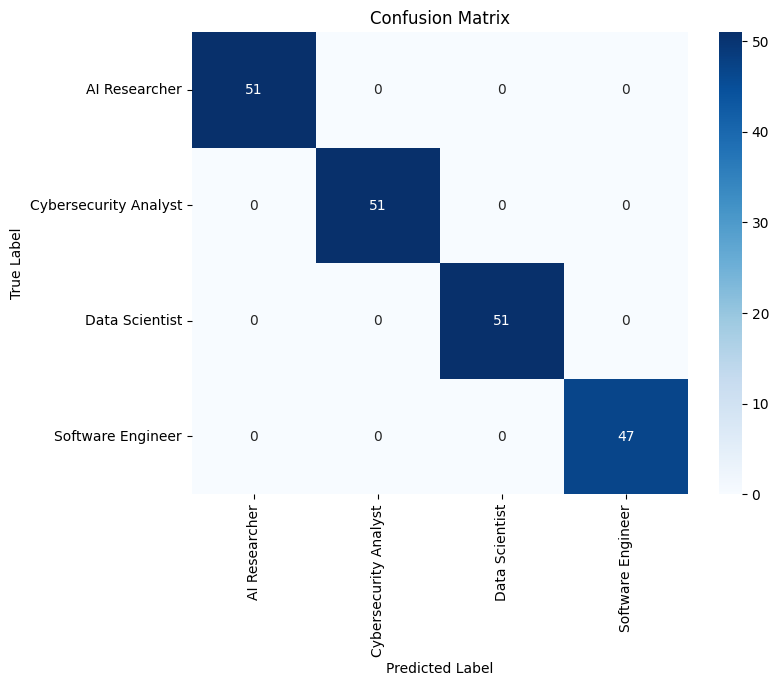

In [15]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Step 8: Feature Analysis

In [16]:
# Extract feature names (words/ngrams) from the TF-IDF vectorizer
feature_names = vectorizer.get_feature_names_out()

# Get the feature importances (coefficients) from the model.
# For Multinomial Naive Bayes, these are log probabilities.
# We will use the 'feature_log_prob_' attribute, which is a matrix of shape (n_classes, n_features).

# Create a DataFrame to store the feature importance for each class
importance_df = pd.DataFrame(model.feature_log_prob_.T, columns=model.classes_, index=feature_names)

print("Top 10 important words for each Job Role:")
for job_role in model.classes_:
    top_features = importance_df.sort_values(by=job_role, ascending=False)[job_role].head(10)
    print(f"\nJob Role: {job_role}")
    print(top_features)

Top 10 important words for each Job Role:

Job Role: AI Researcher
tensorflow           -2.636315
pytorch              -2.657352
nlp                  -2.685617
python               -2.969158
pytorch tensorflow   -3.482445
tensorflow nlp       -3.533519
python nlp           -3.577989
nlp pytorch          -3.618786
tensorflow python    -3.632886
pytorch python       -3.709355
Name: AI Researcher, dtype: float64

Job Role: Cybersecurity Analyst
networking                 -2.763797
cybersecurity              -2.775674
hacking                    -2.784196
ethical                    -2.784196
ethical hacking            -2.784196
linux                      -2.814323
cybersecurity ethical      -3.576914
hacking linux              -3.663721
networking linux           -3.687522
cybersecurity networking   -3.761209
Name: Cybersecurity Analyst, dtype: float64

Job Role: Data Scientist
learning           -2.367006
machine            -2.805529
machine learning   -2.805529
deep               -2.89721

### Step 9: Visualization

/tmp/ipykernel_3283/894431930.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, ax=axes[i], palette='viridis')
/tmp/ipykernel_3283/894431930.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, ax=axes[i], palette='viridis')
/tmp/ipykernel_3283/894431930.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, ax=axes[i], palette='viridis')
/tmp/ipykernel_3283/894431930.py:14: FutureWarning: 

Passing `palette

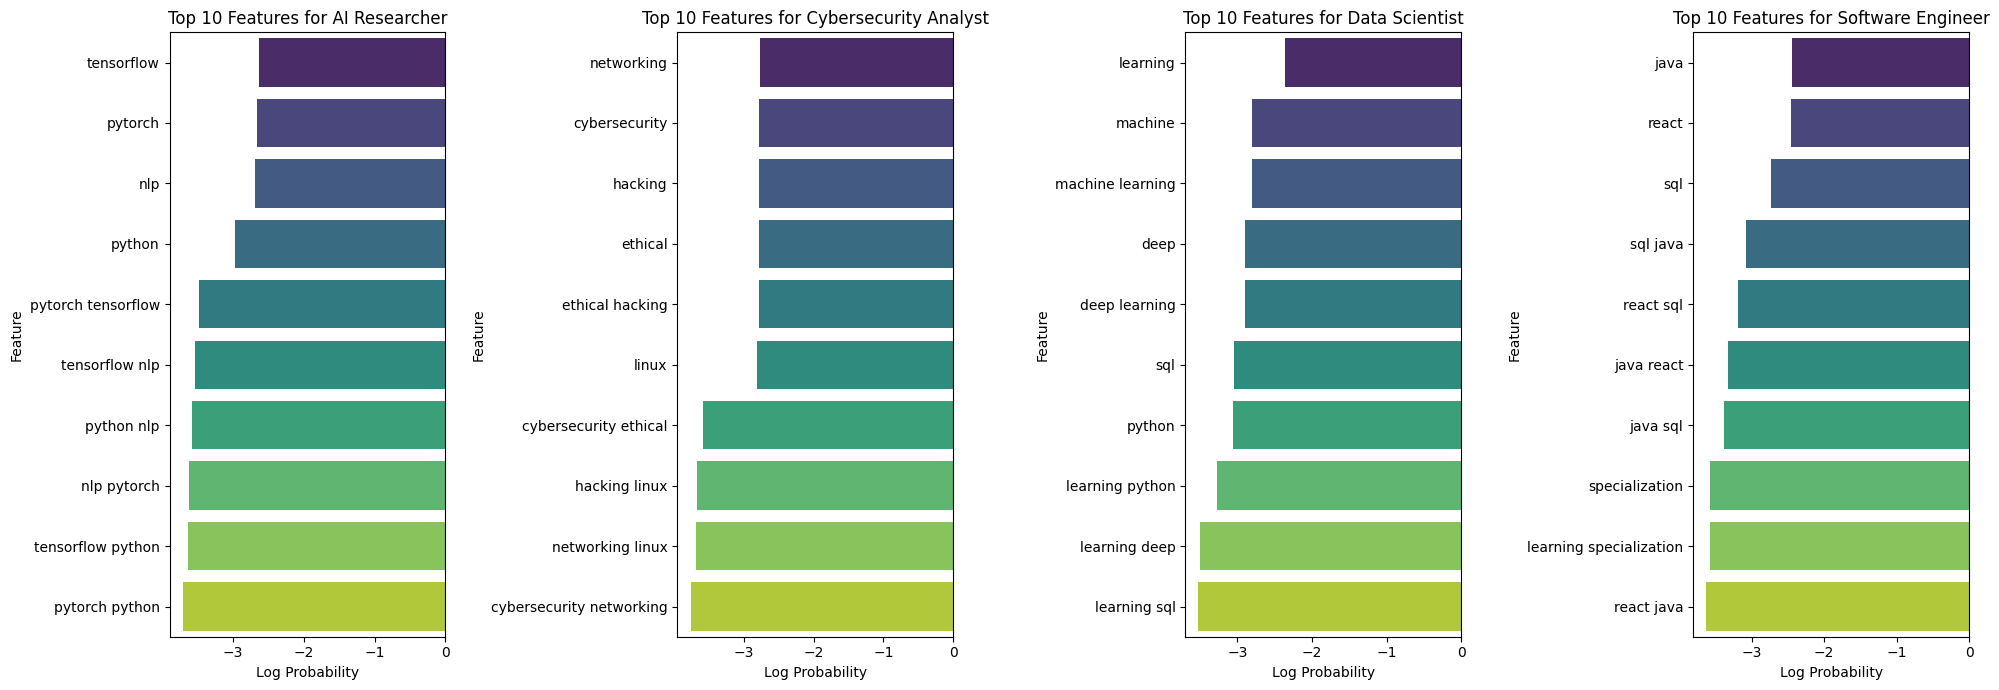

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Function to plot top N features for each class
def plot_top_features(importance_df, n=10):
    num_classes = len(importance_df.columns)
    fig, axes = plt.subplots(1, num_classes, figsize=(5 * num_classes, 7), sharey=False)

    if num_classes == 1:
        axes = [axes] # Ensure axes is iterable for single class case

    for i, job_role in enumerate(importance_df.columns):
        top_features = importance_df.sort_values(by=job_role, ascending=False)[job_role].head(n)
        sns.barplot(x=top_features.values, y=top_features.index, ax=axes[i], palette='viridis')
        axes[i].set_title(f'Top {n} Features for {job_role}')
        axes[i].set_xlabel('Log Probability')
        axes[i].set_ylabel('Feature')

    plt.tight_layout()
    plt.show()

# Plot top 10 features for each job role
plot_top_features(importance_df, n=10)

In [13]:
from sklearn.naive_bayes import MultinomialNB

# Initialize and train the Multinomial Naive Bayes model
model = MultinomialNB()
model.fit(X_train, y_train)

print("Multinomial Naive Bayes model trained successfully.")

Multinomial Naive Bayes model trained successfully.
